### Pilot study, simplified model
June 1, 2026

In [112]:
# === IMPORTS ===
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy

from astropy import units as u
from astropy import constants as const
from pathlib import Path
from time import time
import seaborn as sns
import pickle as pkl

import mmr_id
import rebound_sims as reb_sims

import warnings
warnings.filterwarnings('ignore')

def plot_prettier(dpi=200, fontsize=11, usetex=False): 
    '''
    Make plots look nicer compared to Matplotlib defaults
    Parameters: 
        dpi - int, "dots per inch" - controls resolution of PNG images that are produced
                by Matplotlib
        fontsize - int, font size to use overall
        usetex - bool, whether to use LaTeX to render fonds of axes labels 
                use False if you don't have LaTeX installed on your system
    '''
    plt.rcParams['figure.dpi']= dpi
    plt.rc("savefig", dpi=dpi)
    plt.rc('font', size=fontsize)
    plt.rc('xtick', direction='in') 
    plt.rc('ytick', direction='in')
    plt.rc('xtick.major', pad=5) 
    plt.rc('xtick.minor', pad=5)
    plt.rc('ytick.major', pad=5) 
    plt.rc('ytick.minor', pad=5)
    plt.rc('lines', dotted_pattern = [2., 2.])
    if usetex:
        plt.rc('text', usetex=usetex)
    else:
        plt.rcParams['mathtext.fontset'] = 'cm'
        plt.rcParams['font.family'] = 'serif'
        plt.rcParams['font.serif'] = ['Times New Roman'] + plt.rcParams['font.serif']

plot_prettier()

# === UNIT CONVERSIONS ===
AU = u.AU.to(u.cm)    
G = 4*np.pi**2 # in yr, AU, Msun
Msun = u.Msun.to(u.g) 
yr = u.yr.to(u.s)    
r_earth = u.earthRad.to(u.AU)
m_earth = u.Mearth.to(u.Msun)
r_sun = u.Rsun.to(u.AU) 

#### Load dataset and get general information
Once simulations have been saved, the following code can be used to look at the evolution of orbital elements and period ratios, as well as checking whether there is resonance in the final configuration.

In [113]:
# Process data for any given dataset
dataset_id = 0

all_outcomes = []
outcome_file = f"../sim_results/dataset{dataset_id}/outcomes.pkl"
with open(outcome_file, "rb") as f:
    sim_outcomes = pkl.load(f)
all_outcomes += sim_outcomes
    
n_sims = len(all_outcomes)

columns = [
    "sim_id",
    "m_vals",
    "r_vals",
    "m_star",
    "r_star",
]

outcome_df = pd.DataFrame(all_outcomes, columns=columns)
outcome_df = outcome_df.sort_values(by='sim_id') 

#### Investigate a specific simulation run & plot it

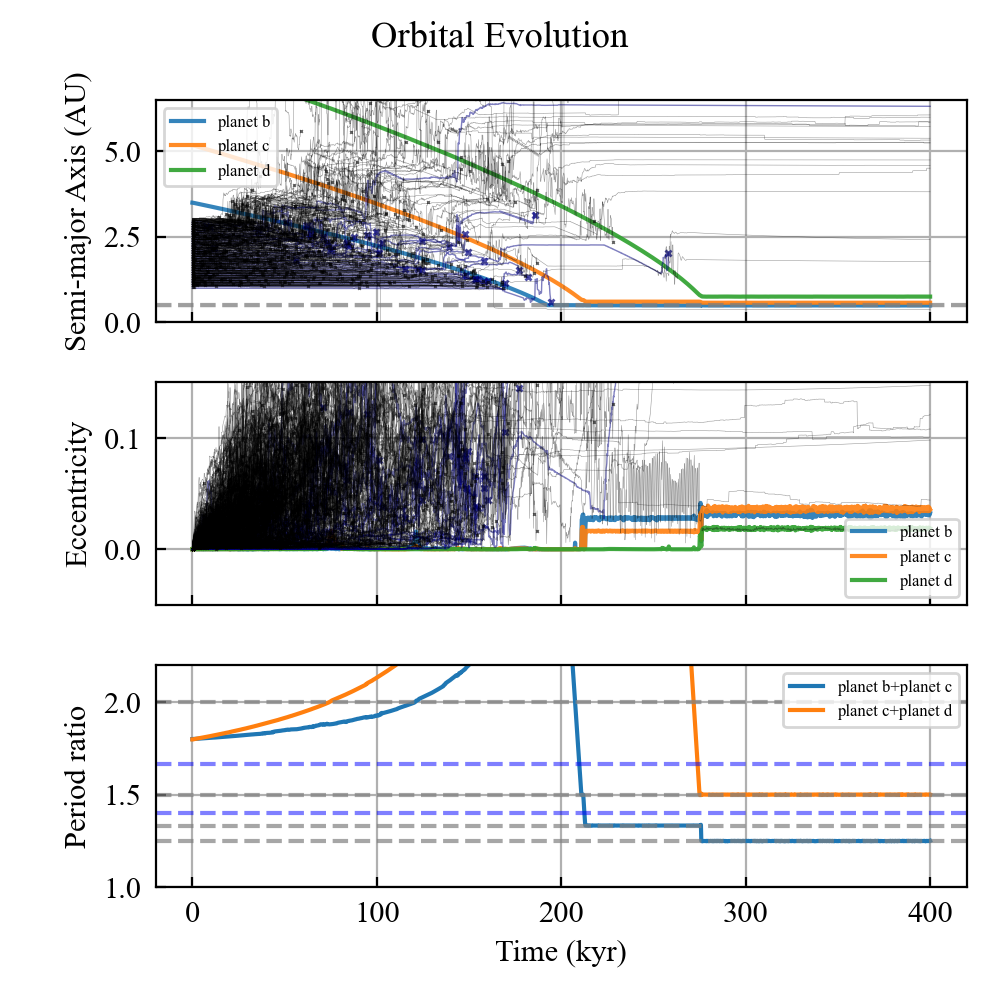

In [129]:
sim_id = 0
base_dir = Path.cwd()
file_path = base_dir.parent / f"sim_results/dataset{dataset_id}" / f"sim{sim_id}.h5"

row = outcome_df.loc[outcome_df["sim_id"] == sim_id].iloc[0]

saved_sim = reb_sims.load_simulation_run(file_path)
sim_data = saved_sim[0]
m_star = saved_sim[1]['m_star'] 
rock_names = saved_sim[1]['rock_names']

rocks = {p: sim_data[p] for p in rock_names}

num_pl, num_em, num_ptsml = saved_sim[1]['num_pl'], saved_sim[1]['num_em'], saved_sim[1]['num_ptsml']

# Example usage
# print(saved_sim[1]['m_star'])
# print(planets['b'][:5])
# print(planets['b']['a'][:5])
# print(planets['b'].attrs["planet_name"])

# === PLOTTING ===

def plot_end_marker(ax, t, y, **kwargs):
    y = np.asarray(y)

    # Find valid entries
    valid = np.isfinite(y)

    # Only plot marker if the object disappears before the end
    if np.any(valid) and not valid[-1]:
        last_idx = np.where(valid)[0][-1]

        ax.plot(
            t[last_idx],
            y[last_idx],
            marker='x',
            linestyle='None',
            **kwargs
        )

def plot_system(sim_data, num_pl, num_em, num_ptsml, t_units='kyr'):
    '''
    Takes dataframes for planets and plots a, e, and P ratios over time.
    '''
    # could also try plotting log
    
    times = sim_data[0]['planet b']['time']
    planet_names = list(sim_data[0].keys())
    
    fig, (ax1, ax2, ax3) = plt.subplots(3, 1, sharex=True)
    fig.set_figwidth(5)
    fig.set_figheight(5)

    time_factor = 1000
    if t_units == 'yr':
        time_factor = 1
    elif t_units == 'Myr': 
        time_factor = 1e6

    for i in range(num_pl):
        name = rock_names[i]

        if t_units == 'kyr':
            ax1.plot(times/time_factor,sim_data[0][name]["a"], alpha=0.9, label=name)
            ax2.plot(times/time_factor, sim_data[0][name]["e"], alpha=0.9, label=name)
            plot_end_marker(ax1, times/time_factor, sim_data[0][name]["a"], ms=5, mew=2.5)
            plot_end_marker(ax2, times/time_factor, sim_data[0][name]["e"], ms=5, mew=2.5)
    
        if i != num_pl-1:
            ax3.plot(times/time_factor, sim_data[0][name]["P_ratio"], label=f"{name}+{rock_names[i+1]}")
    
    for i in range(num_em):
        name = rock_names[i+num_pl]
        
        if t_units == 'kyr':
            ax1.plot(times/time_factor, sim_data[0][name]["a"], c='navy', alpha=0.5, lw=0.5)
            ax2.plot(times/time_factor, sim_data[0][name]["e"], c='navy', alpha=0.5, lw=0.5)
            plot_end_marker(ax1, times/time_factor, sim_data[0][name]["a"], color='navy', ms=2, mew=1, alpha=0.7)
            plot_end_marker(ax2, times/time_factor, sim_data[0][name]["e"], color='navy', ms=2, mew=1, alpha=0.7)
    
    for i in range(num_ptsml):
        name = rock_names[i+num_pl+num_em]
        
        if t_units == 'kyr':
            ax1.plot(times/time_factor, sim_data[0][name]["a"], c='k', alpha=0.4, lw=0.2)
            ax2.plot(times/time_factor, sim_data[0][name]["e"], c='k', alpha=0.4, lw=0.2)
            plot_end_marker(ax1, times/time_factor, sim_data[0][name]["a"], color='k', ms=1, mew=0.5, alpha=0.6)
            plot_end_marker(ax2, times/time_factor, sim_data[0][name]["e"], color='k', ms=1, mew=0.5, alpha=0.6)
    
    ax1.set_ylabel("Semi-major Axis (AU)")
    ax2.set_ylabel("Eccentricity")
    ax3.set_ylabel("Period ratio")
    ax3.set_xlabel("Time (kyr)")
    
    ax1.set_ylim(0,6.5)
    ax2.set_ylim(-0.05,0.15)
    ax3.set_ylim(1,2.2)
    
    # Plot ide location & width
    try:
        ax1.axhline(sim_data[1]["ide_position"], color='gray', ls='--', alpha=0.7)
        ax1.axhline(sim_data[1]["ide_position"] - sim_data[1]["ide_width"], color='gray', ls='--', alpha=0.1)
        ax1.axhline(sim_data[1]["ide_position"] + sim_data[1]["ide_width"], color='gray', ls='--', alpha=0.1)
    except:
        pass

    ax1.legend(fontsize=6); ax2.legend(fontsize=6); ax3.legend(fontsize=6)
    ax1.grid(True); ax2.grid(True); ax3.grid(True)
    
    # Add horizontal lines for resonances
    resonances_1 = [2/1, 3/2, 4/3, 5/4]
    resonances_2 = [3/1, 5/3, 7/5]
    resonances_3 = [4/1, 5/2, 7/4, 8/5]
    for r in resonances_1:
        ax3.axhline(r, color='gray', ls='--', alpha=0.7)
    for r in resonances_2:
        ax3.axhline(r, color='blue', ls='--', alpha=0.5)
    # for r in resonances_3:
    #     ax3.axhline(r, color='red', ls='--', alpha=0.5)

    fig.subplots_adjust(hspace=0)

    plt.suptitle("Orbital Evolution")
    plt.tight_layout(); plt.show()
    
%matplotlib widget
plot_system(saved_sim, num_pl, num_em, num_ptsml)

In [126]:
def summarize_accretion(metadata):
    """Display collision log, particle fates, and accretion statistics.
    Metadata should typically come from saved_sim[1].
    """

    # === Collision log ===
    collision_df = pd.DataFrame(metadata["collision_log"])
    collision_df["time"] = (collision_df["time"] / 1000).round(1)
    collision_df = collision_df.rename(columns={"time": "time (kyr)"})
    collision_df = collision_df.sort_values("time (kyr)")
    collision_df["victim mass"] = (collision_df["victim mass"] / m_earth).round(2)
    collision_df = collision_df.rename(columns={"victim mass": "victim mass (m_earth)"})
    
    # print("Collision Log")
    # display(collision_df)
    
    # === Particle fates ===
    fate_df = (pd.Series(metadata["particle_fate"]).rename("outcome"))
    
    # Omit alive particles
    fate_df = fate_df[fate_df != "alive"]  
    fate_df = fate_df.sort_values()
    fate_df = fate_df.to_frame() 
    
    # print("Particle Fates")
    # display(fate_df)

    # === Accretion Statistics ===
    accretion_df = pd.DataFrame(metadata["accretion_stats"]).T

    # Integer counts
    for col in ["embryos", "ptsmls"]:
        if col in accretion_df.columns:
            accretion_df[col] = (
                accretion_df[col]
                .fillna(0)
                .astype(int)
            )

    # Keep only objects that accreted something
    keep = pd.Series(False, index=accretion_df.index)
    keep |= accretion_df["embryos"] > 0
    keep |= accretion_df["ptsmls"] > 0
    keep |= accretion_df["mass"] > 0
    
    accretion_df["mass"] = (accretion_df["mass"] / m_earth).round(2)
    accretion_df["mass"] = accretion_df["mass"] + 0.0033 * accretion_df["ptsmls"]
    accretion_df = accretion_df.sort_values("mass", ascending=False) # sort by accreted mass
    accretion_df = accretion_df.rename(columns={"mass": "mass (m_earth)"})
    accretion_df = accretion_df[keep]
    
    accretion_df["embryo %"] = (
        100 * accretion_df["embryos"] / num_em
    ).round(1)

    accretion_df["ptsml %"] = (
        100 * accretion_df["ptsmls"] / num_ptsml
    ).round(1)

    print("Accretion Statistics")
    display(accretion_df)

    return collision_df, fate_df, accretion_df

collision_df, fate_df, accretion_df = summarize_accretion(saved_sim[1])

Accretion Statistics


,embryos,ptsmls,mass (m_earth),embryo %,ptsml %
planet b,16,128,0.6424,40.0,17.1
planet d,2,18,0.1394,5.0,2.4
planet c,3,31,0.1323,7.5,4.1
embryo 35,7,14,0.1162,17.5,1.9
embryo 20,2,22,0.0926,5.0,2.9
embryo 11,4,9,0.0897,10.0,1.2
embryo 23,1,20,0.0760,2.5,2.7
embryo 13,1,20,0.0760,2.5,2.7
embryo 17,1,18,0.0694,2.5,2.4
embryo 4,1,17,0.0661,2.5,2.3


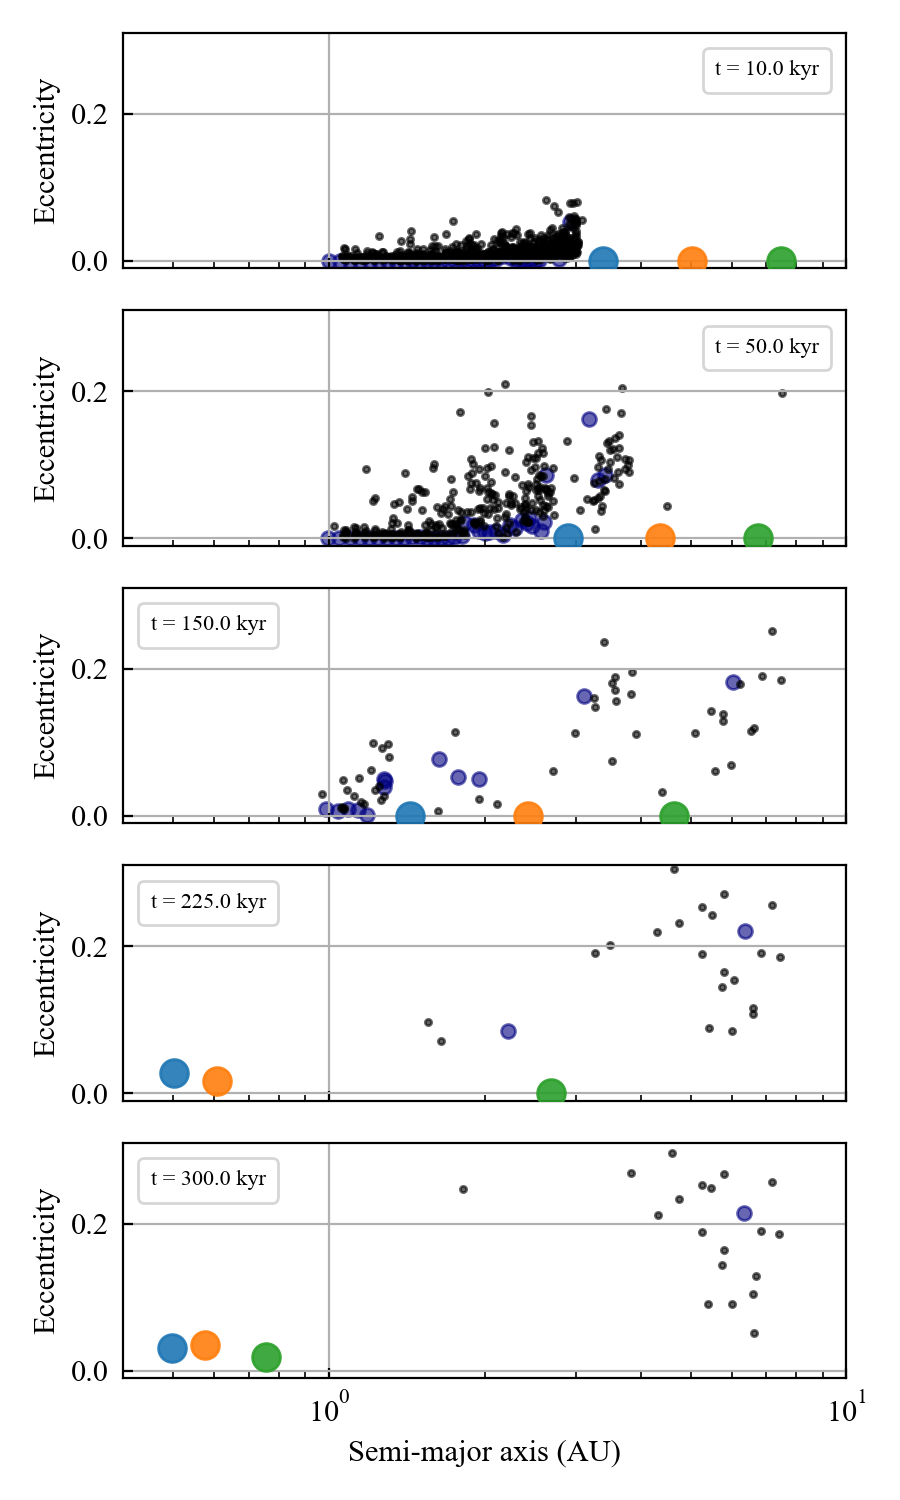

In [132]:
def plot_ae_snapshot(saved_sim, *snapshot_times):
    """Plot a vs e at a one or more snapshots.
    """

    sim_data = saved_sim[0]

    # Use first body to get time array
    first_name = rock_names[0]
    times = sim_data[first_name]["time"]

    # Get idxs that best match the times given
    snapshot_idxs = np.array([
        np.argmin(np.abs(times - t))
        for t in snapshot_times
    ]) 

    num_plots = len(snapshot_times)
    fig, axs = plt.subplots(num_plots, 1, sharex=True, figsize=(4.5, 1.5 * num_plots))

    for i, ax in enumerate(axs):
        snapshot_idx = snapshot_idxs[i]
        
        # planets
        for j in range(num_pl):
            name = rock_names[j]

            ax.scatter(
                sim_data[name]["a"][snapshot_idx],
                sim_data[name]["e"][snapshot_idx],
                s=100,
                # label=name,
                zorder=3,
                alpha=0.9
            )

        # embryos
        for j in range(num_em):
            name = rock_names[num_pl + j]

            ax.scatter(
                sim_data[name]["a"][snapshot_idx],
                sim_data[name]["e"][snapshot_idx],
                s=25,
                color='navy',
                alpha=0.6
            )

        # planetesimals
        for j in range(num_ptsml):
            name = rock_names[num_pl + num_em + j]

            ax.scatter(
                sim_data[name]["a"][snapshot_idx],
                sim_data[name]["e"][snapshot_idx],
                s=5,
                c='k',
                alpha=0.6
            )

        if i == num_plots - 1:
            ax.set_xlabel("Semi-major axis (AU)")
        ax.set_ylabel("Eccentricity")
        ax.set_ylim(-0.01, 0.31)
        ax.set_xlim(0.4, 10)
        ax.set_xscale('log')
        ax.grid(True)

        t = times[snapshot_idx]
        ax.legend(title=f"t = {t/1000:.1f} kyr", title_fontsize=8, labelspacing=0)
        
    fig.subplots_adjust(hspace=0)
    plt.tight_layout()
    plt.show()
    
plot_ae_snapshot(saved_sim, 10e3, 50e3, 150e3, 225e3, 300e3)

In [117]:
def plot_taus(sim_data, num_pl, num_em, num_ptsml, t_units='kyr'):
    '''
    Takes dataframes for planets and plots a, e, and P ratios over time.
    '''
    times = sim_data[0]['planet b']['time']
    planet_names = list(sim_data[0].keys())
    
    fig, (ax1, ax2, ax3) = plt.subplots(3, 1, sharex=True)
    fig.set_figwidth(7)
    fig.set_figheight(7)

    for i in range(num_em):
        # could also try plotting log
        name = rock_names[i+num_pl]
        
        if t_units == 'kyr':
            ax1.plot(times/1000, sim_data[0][name]["tau_a"], label=name)
            ax2.plot(times/1000, sim_data[0][name]["tau_e"], label=name)
            ax3.plot(times/1000, sim_data[0][name]["tau_i"], label=name)
            plt.xlabel("Time (kyr)")
            
    ax1.set_ylabel("tau_a")
    ax2.set_ylabel("tau_e")
    ax3.set_ylabel("tau_i")
    
    # ax1.set_ylim(0,5)
    # ax2.set_ylim(-0.1,0.45)
    # ax3.set_ylim(1,2.2)
    
    ax1.legend(); ax2.legend(); ax3.legend()
    ax1.grid(True); ax2.grid(True); ax3.grid(True)

    fig.subplots_adjust(hspace=0)

    plt.suptitle("Orbital Evolution")
    plt.tight_layout(); plt.show()
    
# plot_taus(saved_sim, num_pl, num_em, num_ptsml)

True period ratio: 1.2509
p, q: 5, 4
Libration amplitude: 2.7 deg


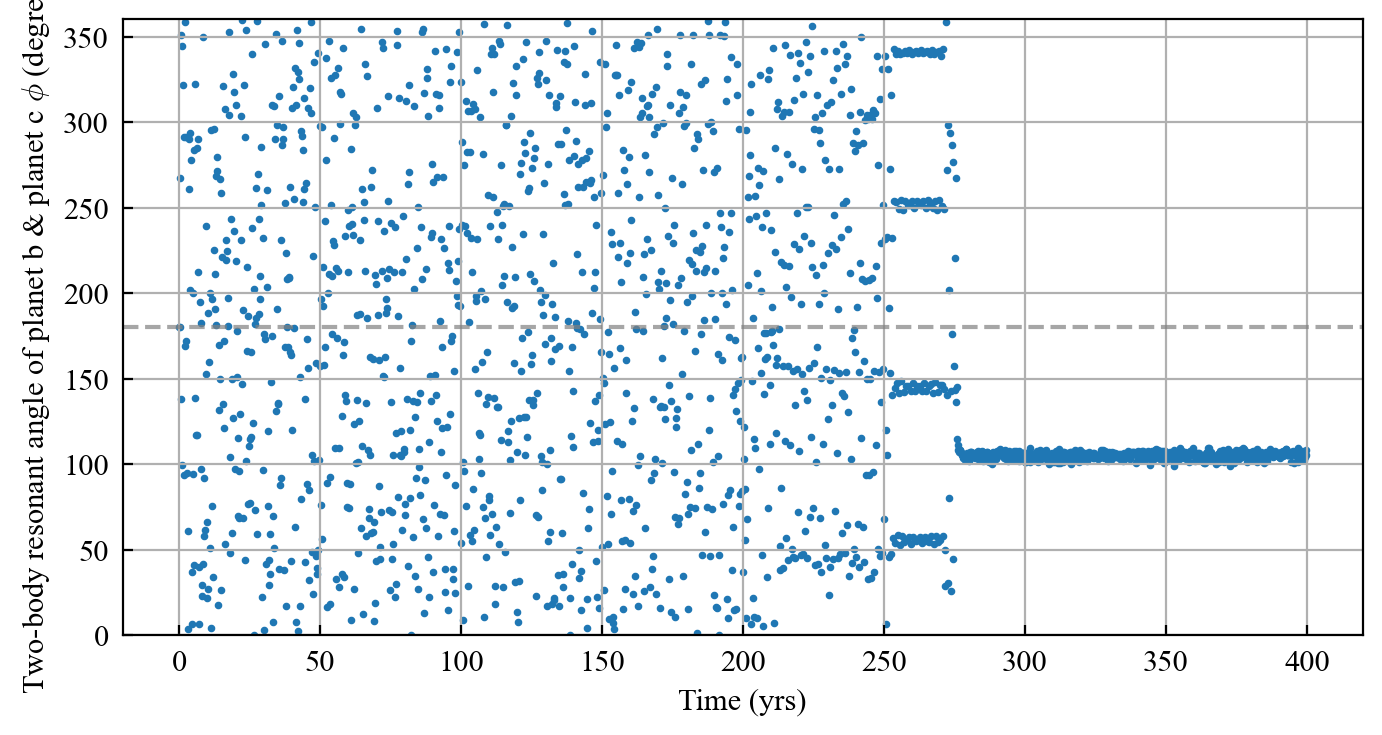

In [118]:
mmr_id.plot_libration(m_star, rocks['planet b'], rocks['planet c'])